In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Download NLP resources
nltk.download(['stopwords', 'vader_lexicon', 'punkt', 'punkt_tab']) # Added 'punkt_tab'

# Load dataset
df = pd.read_csv('new_krish_youtube_comments.csv')

# Text cleaning function
def clean_text(text):
    # Check if text is a string before processing
    if not isinstance(text, str):
        return ""  # Return empty string for non-string inputs

    # Remove URLs, special characters, and numbers
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Lowercase and remove stopwords
    text = text.lower()
    stop_words = set(stopwords.words('english'))
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in stop_words and len(word) > 2]

    return " ".join(words)

# Apply cleaning
df['cleaned_text'] = df['sentiment'].apply(clean_text)

# Initialize sentiment analyzers
sia = SentimentIntensityAnalyzer()

# Sentiment scoring function
def get_sentiment_scores(text):
    # Check if text is a string before processing
    if not isinstance(text, str):
        return 0.0  # Return a neutral score for non-string inputs

    # VADER for social media-optimized scoring
    vader_score = sia.polarity_scores(text)['compound']

    # TextBlob for polarity/subjectivity
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # Combined score (weighted average)
    return 0.6*vader_score + 0.4*polarity

# Calculate sentiment scores
df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment_scores)

# Classify sentiment
df['sentiment_label'] = df['sentiment_score'].apply(
    lambda x: 'positive' if x > 0.1 else 'negative' if x < -0.1 else 'neutral'
)

# Save enhanced dataset
df.to_csv('youtube_comments_sentiment.csv', index=False)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Create directed graph from reply relationships
G = nx.DiGraph()

# Add nodes with sentiment attributes
user_sentiments = df.groupby('author_channel_id')['sentiment_score'].mean()
for user, score in user_sentiments.items():
    G.add_node(user, sentiment=score)

# Add edges with interaction weights
for _, row in df.iterrows():
    if not pd.isna(row['parent_id']):
        parent = df[df['comment_id'] == row['parent_id']]
        if not parent.empty:
            source = row['author_channel_id']
            target = parent['author_channel_id'].values[0]
            if source != target and source in G.nodes and target in G.nodes:
                if G.has_edge(source, target):
                    G[source][target]['weight'] += 1
                else:
                    G.add_edge(source, target, weight=1, 
                               init_sentiment=G.nodes[target]['sentiment'])

# Calculate sentiment propagation metrics
for u, v, data in G.edges(data=True):
    delta = G.nodes[u]['sentiment'] - data['init_sentiment']
    G[u][v]['sentiment_influence'] = delta

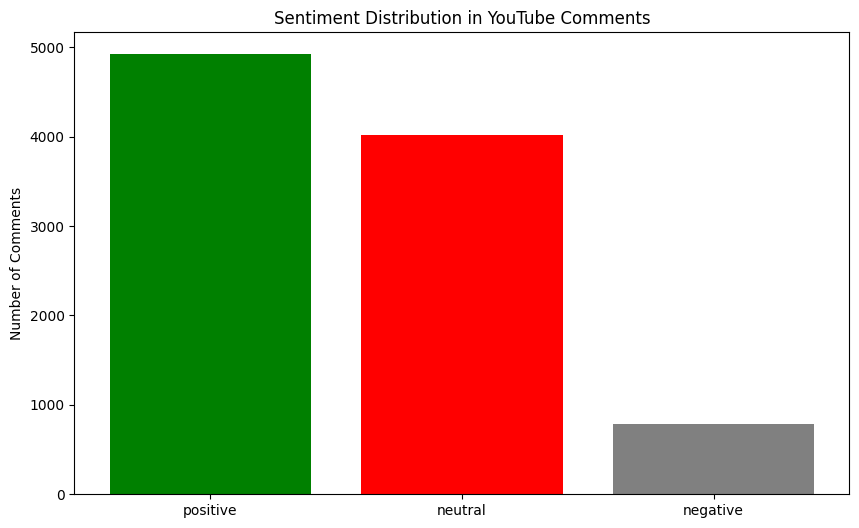

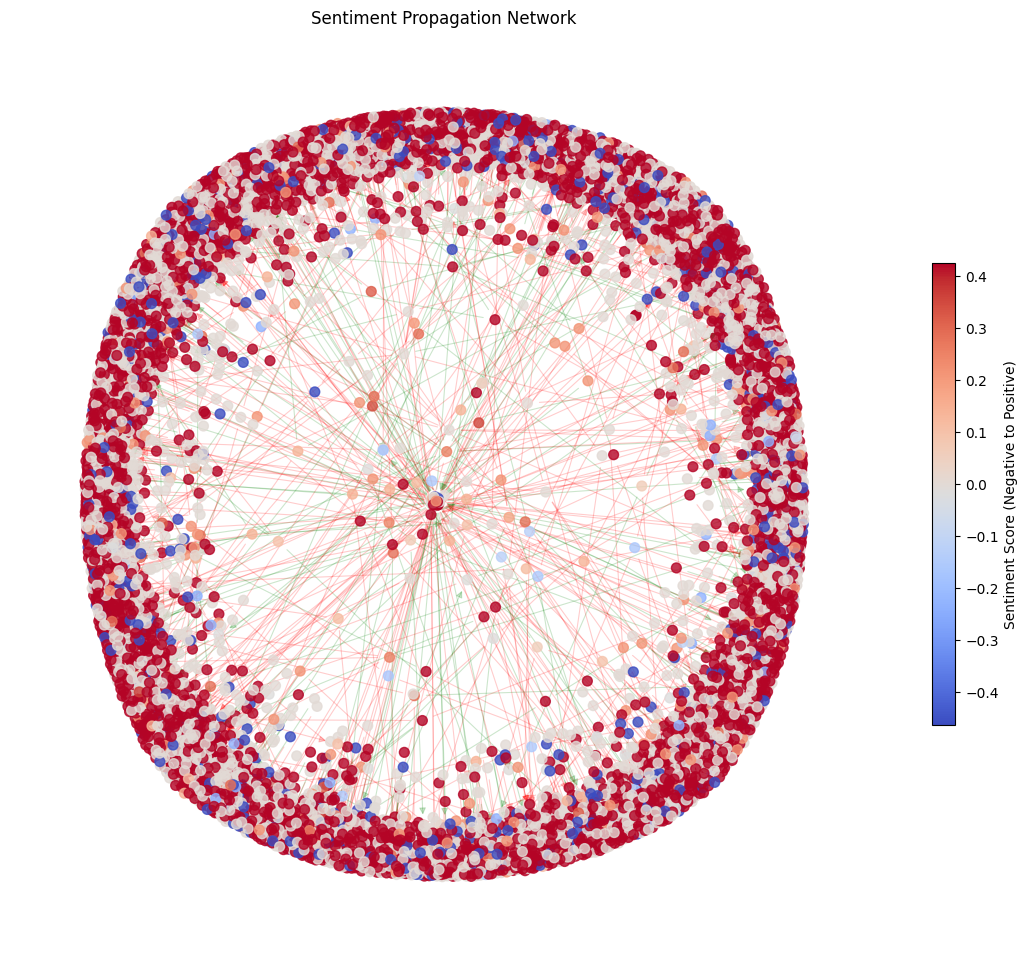

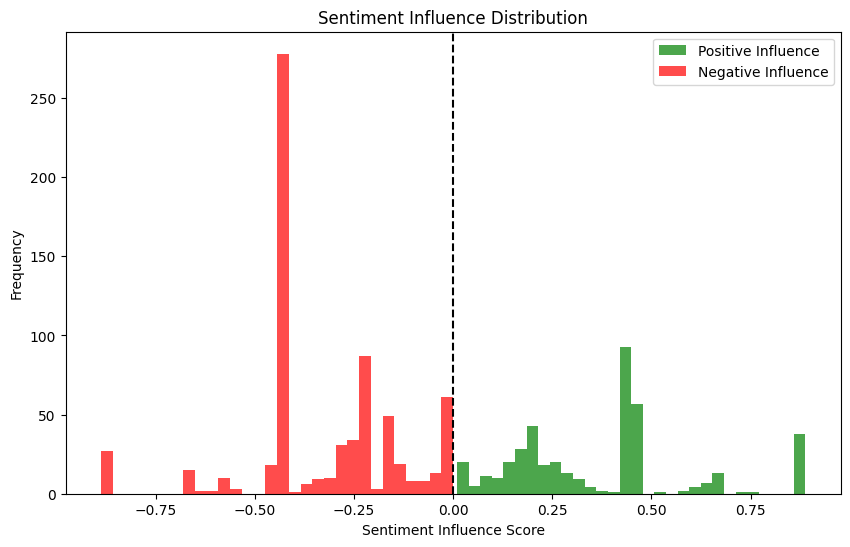

In [7]:
# Sentiment distribution plot
plt.figure(figsize=(10, 6))
sentiment_counts = df['sentiment_label'].value_counts()
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution in YouTube Comments')
plt.ylabel('Number of Comments')
plt.savefig('sentiment_distribution.png', dpi=300)

# Network visualization with sentiment coloring
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42)

# Node colors by sentiment
node_colors = [G.nodes[n]['sentiment'] for n in G.nodes]
vmin, vmax = min(node_colors), max(node_colors)

# Edge colors by influence
edge_colors = []
for u, v in G.edges():
    if 'sentiment_influence' in G[u][v]:
        if G[u][v]['sentiment_influence'] > 0:
            edge_colors.append('green')  # Positive influence
        else:
            edge_colors.append('red')   # Negative influence
    else:
        edge_colors.append('gray')       # Neutral

# Draw network
nx.draw_networkx_nodes(
    G, pos,
    node_size=50,
    node_color=node_colors,
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    alpha=0.8
)
nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    alpha=0.2,
    width=0.8
)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
# Explicitly provide the axes to the colorbar
cbar = plt.colorbar(sm, shrink=0.5, ax=plt.gca())
cbar.set_label('Sentiment Score (Negative to Positive)')

plt.title('Sentiment Propagation Network')
plt.axis('off')
plt.savefig('sentiment_propagation_network.png', dpi=300, bbox_inches='tight')
plt.show()

# Sentiment correlation analysis
positive_edges = [G[u][v]['sentiment_influence'] for u,v in G.edges()
                 if 'sentiment_influence' in G[u][v] and G[u][v]['sentiment_influence'] > 0]
negative_edges = [G[u][v]['sentiment_influence'] for u,v in G.edges()
                 if 'sentiment_influence' in G[u][v] and G[u][v]['sentiment_influence'] < 0]

plt.figure(figsize=(10, 6))
plt.hist(positive_edges, bins=30, alpha=0.7, color='green', label='Positive Influence')
plt.hist(negative_edges, bins=30, alpha=0.7, color='red', label='Negative Influence')
plt.axvline(0, color='black', linestyle='--')
plt.title('Sentiment Influence Distribution')
plt.xlabel('Sentiment Influence Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('sentiment_influence_histogram.png', dpi=300)